In [ ]:
# ============================================================
# voiced_multiclass_clustering.py  ── Colab ready
#   window_sec=1.0 | hop_sec=0.25 | sr=16000
#   219维 handcrafted acoustics, record-level mean aggregation
#
# Part 1 ── 疾病三分类 监督学习
#           hyperkinetic / hypokinetic / laryngitis
#           5-fold stratified CV | CatBoost / RF / ExtraTrees / SVM / GBDT / Lasso
#
# Part 2 ── 疾病三分类 无监督聚类 (k=3) + Hungarian 对齐 → 真实标签对比
#           K-Means / Agglomerative Ward / GMM
#
# Part 3 ── 可视化
#           t-SNE | 混淆矩阵 | 聚类指标 | 监督 vs 无监督对比
#
# ============================================================


In [ ]:
# ── Cell 0: 安装catboost ──────────────────────────────────────────
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
# ── Cell 1: 导入 ──────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import io, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score,
    adjusted_rand_score, adjusted_mutual_info_score,
    normalized_mutual_info_score, silhouette_score,
    davies_bouldin_score, homogeneity_score, completeness_score,
    v_measure_score,
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)

In [ ]:
# ── Cell 2: 上传文件 ──────────────────────────────────────────

from google.colab import files

print("请上传 CSV 文件")
uploaded = files.upload()

fname      = list(uploaded.keys())[0]
raw_upload = pd.read_csv(io.BytesIO(uploaded[fname]))
print(f"\n上传: {fname}  shape={raw_upload.shape}")

WINDOW_META = {"record_id", "window_index", "label", "class_group",
               "age", "vhi", "rsi", "gender_male"}

if "window_index" in raw_upload.columns:
    print("检测到 window-level，正在聚合到 record-level…")
    _feat_tmp = [c for c in raw_upload.columns if c not in WINDOW_META]
    raw = (
        raw_upload
        .groupby("record_id")[_feat_tmp + ["class_group", "label"]]
        .agg({**{c: "mean" for c in _feat_tmp},
              "class_group": "first", "label": "first"})
        .reset_index()
    )
    print(f"聚合完成 → {raw.shape[0]} records × {raw.shape[1]} columns")
else:
    print("检测到 record-level，直接使用。")
    raw = raw_upload.copy()

OUTPUT_DIR = "voiced_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 类别常量（与预设的 MULTICLASS_ORDER 一致）
DISEASE_ORDER = ["hyperkinetic", "hypokinetic", "laryngitis"]
CLASS_ORDER   = ["healthy", "hyperkinetic", "hypokinetic", "laryngitis"]
DIS_COLORS = {
    "hyperkinetic": "#2196F3",
    "hypokinetic":  "#FF9800",
    "laryngitis":   "#E91E63",
}

请上传 CSV 文件


Saving binary_window_features_sr16000_w1p0_h0p25.csv to binary_window_features_sr16000_w1p0_h0p25.csv

上传: binary_window_features_sr16000_w1p0_h0p25.csv  shape=(3510, 227)
检测到 window-level，正在聚合到 record-level…
聚合完成 → 208 records × 222 columns


Records: 208  |  Features: 219

Full class distribution:
class_group
hyperkinetic    72
healthy         57
hypokinetic     41
laryngitis      38

Disease-only records: 151
class_group
hyperkinetic    72
hypokinetic     41
laryngitis      38

── Computing PCA & t-SNE (disease samples only) ──
PCA-50 cumulative variance: 0.958
Running t-SNE…
Done.

PART 1: 疾病三分类 Supervised (5-fold CV)

[CatBoost]  ACC=0.5298  BalACC=0.5172  MacroF1=0.5176  MacroOvR-AUC=0.6970
              precision    recall  f1-score   support

hyperkinetic       0.57      0.57      0.57        72
 hypokinetic       0.57      0.56      0.57        41
  laryngitis       0.41      0.42      0.42        38

    accuracy                           0.53       151
   macro avg       0.52      0.52      0.52       151
weighted avg       0.53      0.53      0.53       151


[RandomForest]  ACC=0.5298  BalACC=0.4684  MacroF1=0.4771  MacroOvR-AUC=0.7121
              precision    recall  f1-score   support

hyperkinetic       0.5

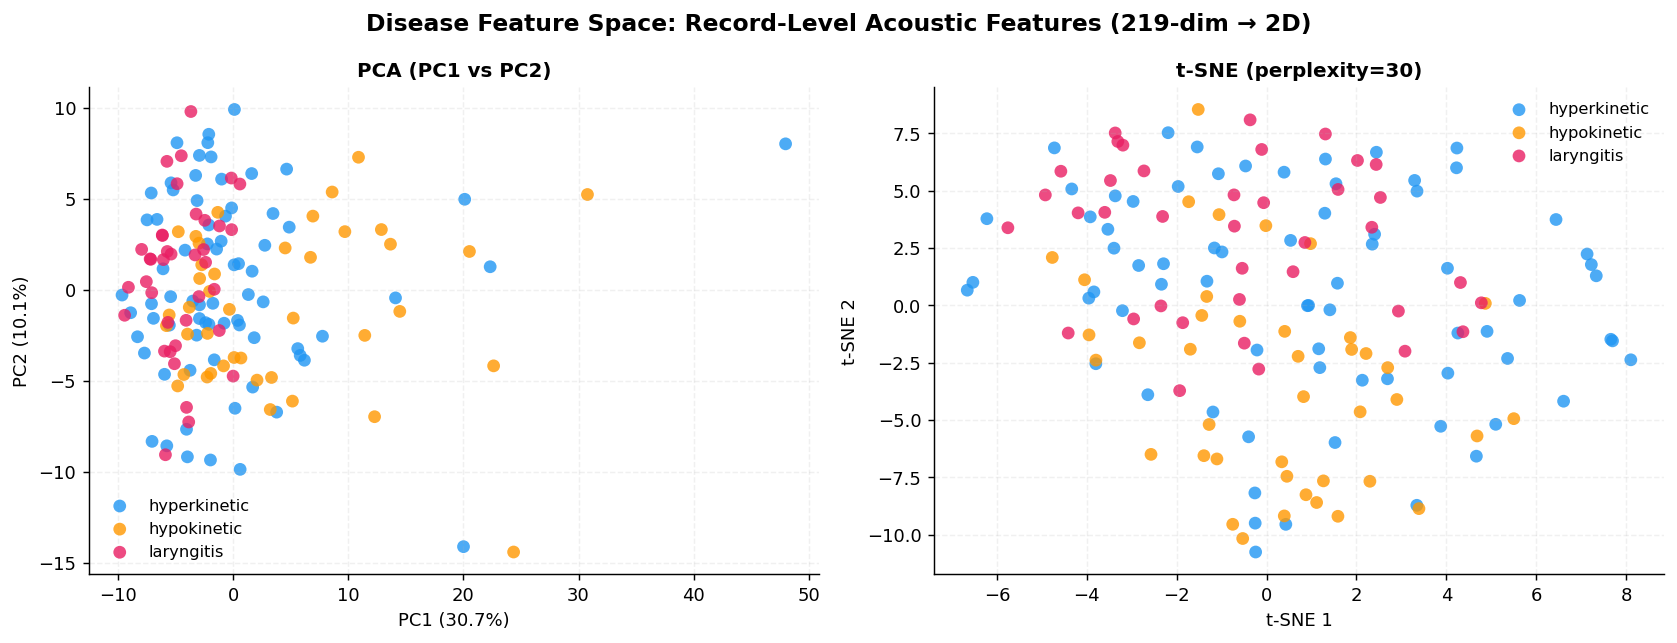

✅ fig1 saved


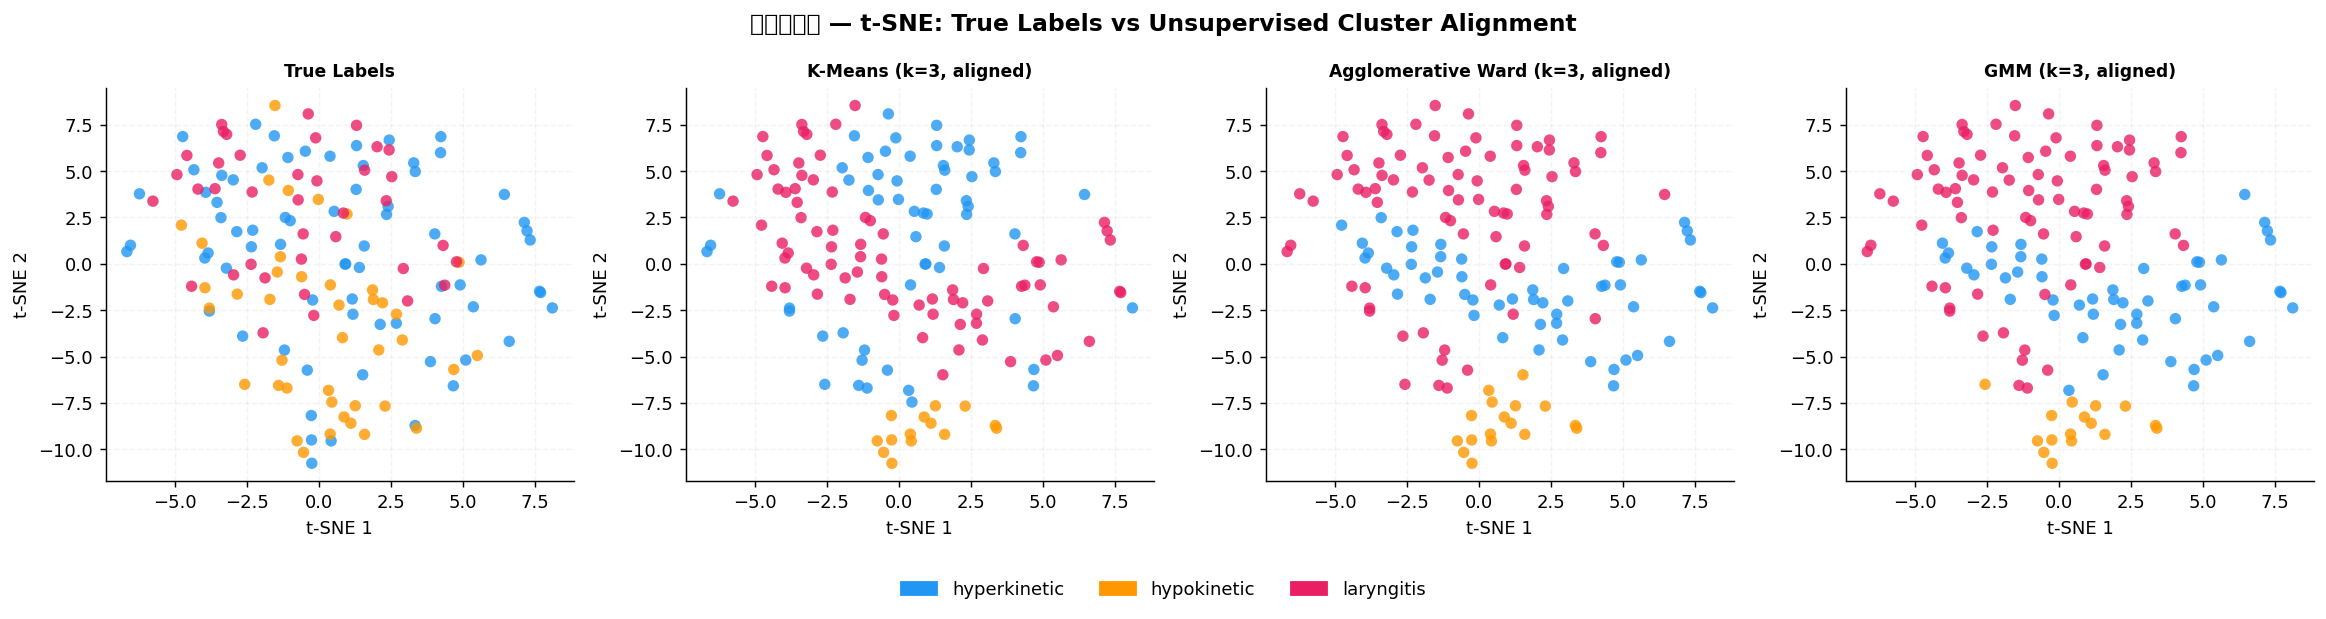

✅ fig2 saved


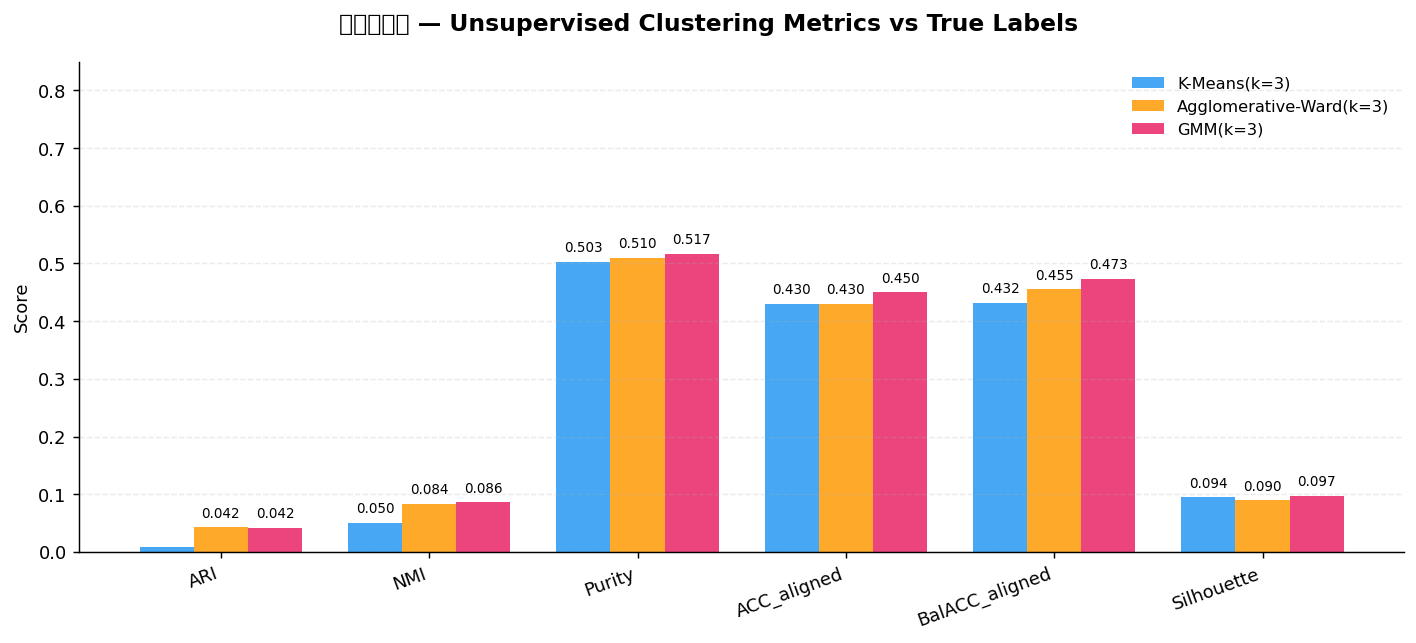

✅ fig3 saved


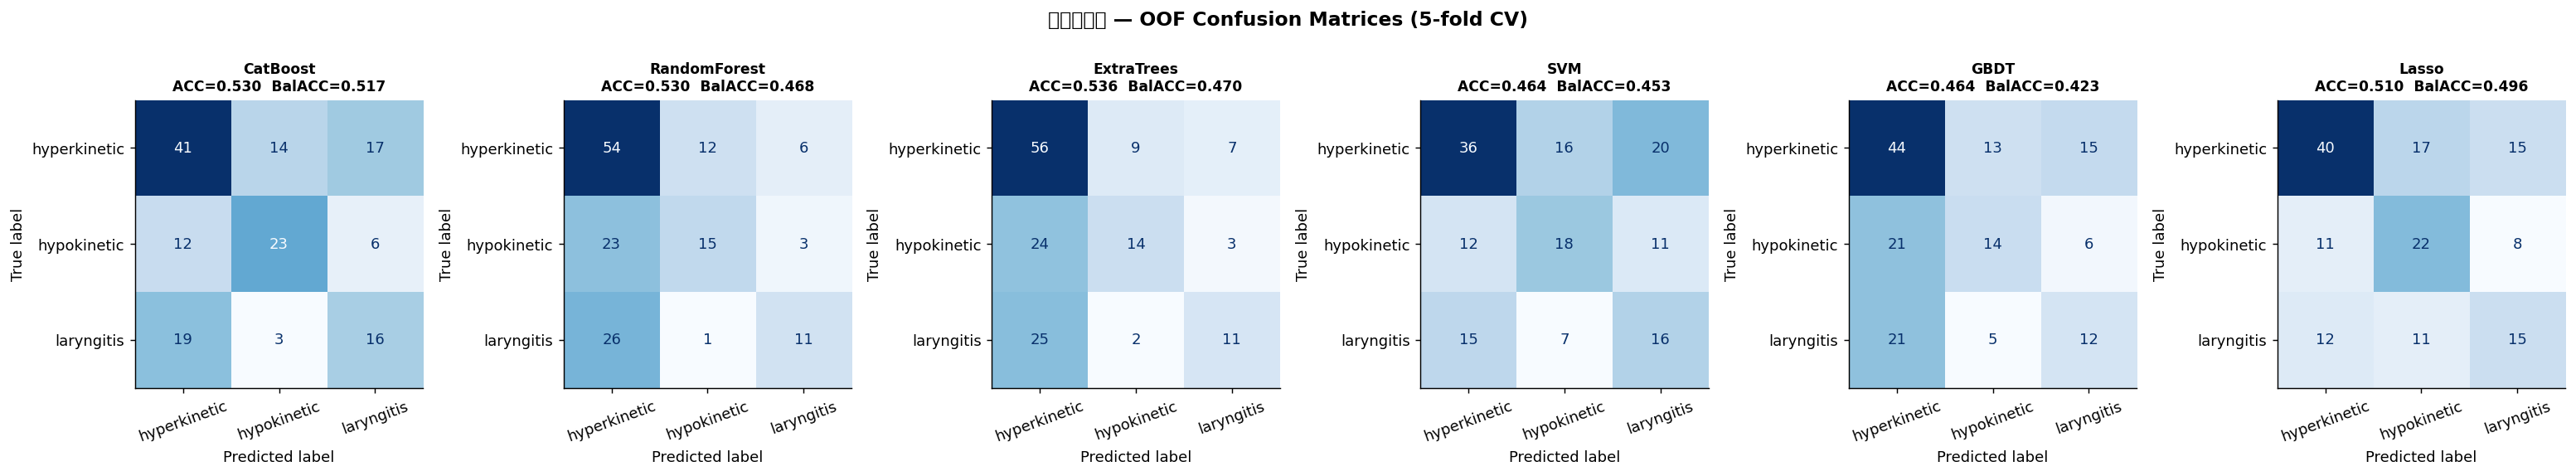

✅ fig4 saved


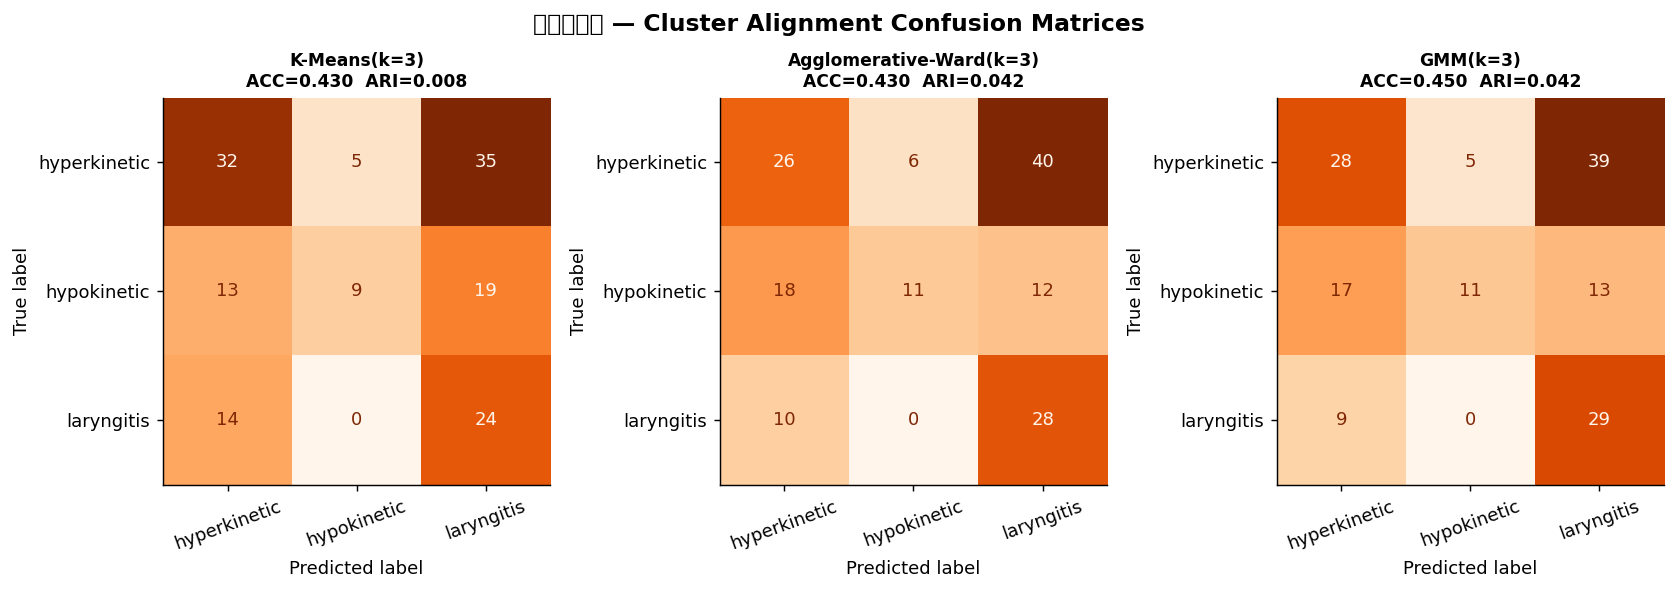

✅ fig5 saved


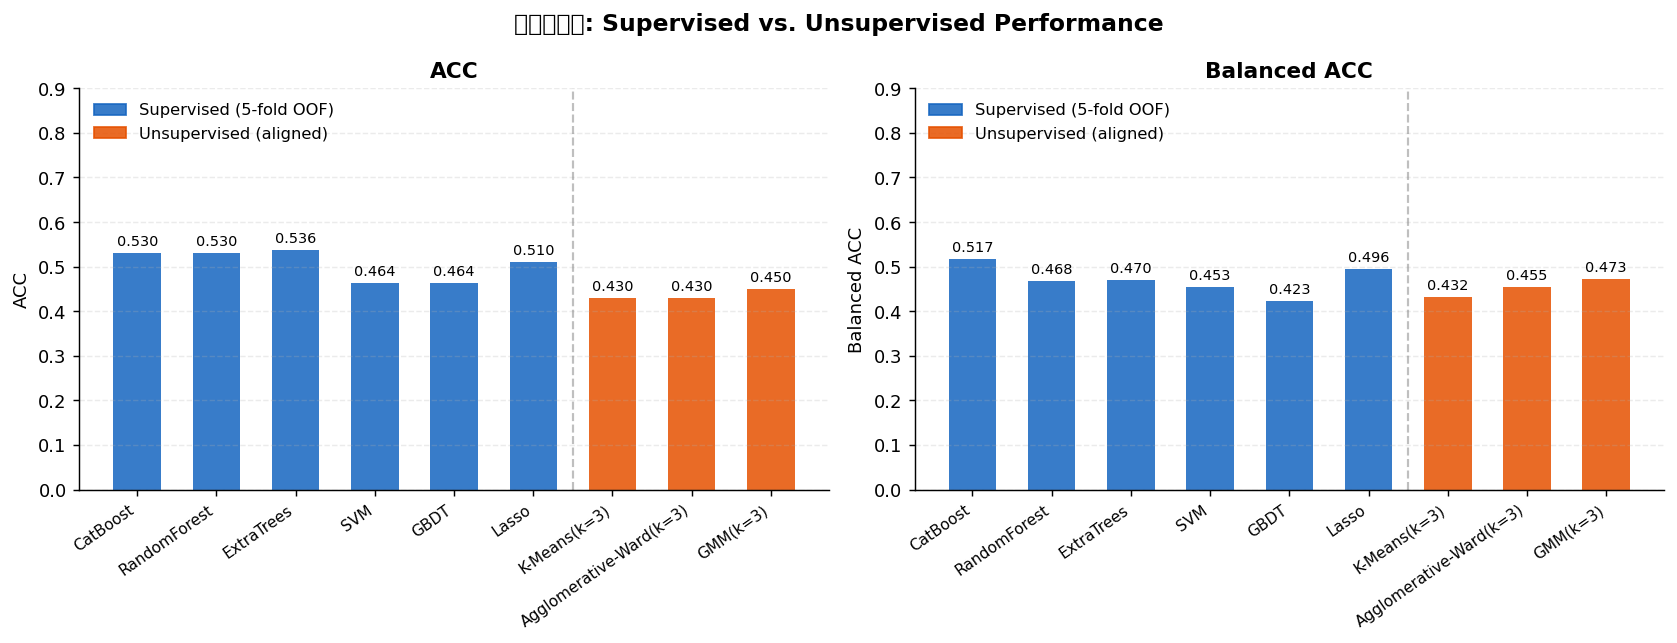

✅ fig6 saved


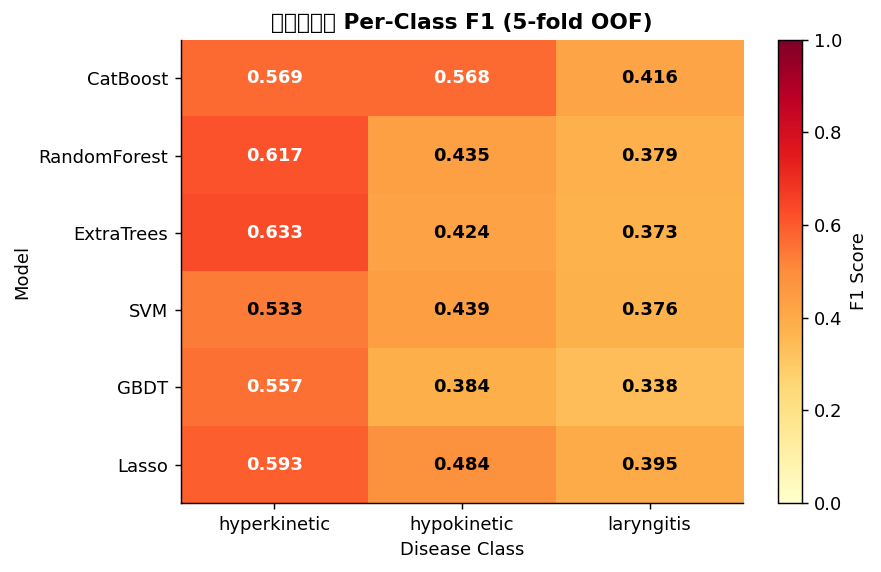

✅ fig7 saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL DONE

[疾病三分类 Supervised]
       Model  OOF_ACC  BalACC  Macro_F1  Macro_OvR_AUC
    CatBoost   0.5298  0.5172    0.5176         0.6970
       Lasso   0.5099  0.4956    0.4903         0.6839
  ExtraTrees   0.5364  0.4696    0.4766         0.6995
RandomForest   0.5298  0.4684    0.4771         0.7121
         SVM   0.4636  0.4534    0.4496         0.6705
        GBDT   0.4636  0.4228    0.4262         0.6509

[疾病三分类 Clustering]
                 Method    ARI    NMI  Purity  ACC_aligned  BalACC_aligned  Silhouette
           K-Means(k=3) 0.0082 0.0503  0.5033       0.4305          0.4318      0.0944
Agglomerative-Ward(k=3) 0.0424 0.0835  0.5099       0.4305          0.4554      0.0900
               GMM(k=3) 0.0422 0.0865  0.5166       0.4503          0.4734      0.0974


In [ ]:
# ── Cell 3: 确认数据 ──────────────────────────────────────────
META_COLS = ["record_id", "class_group", "label"]
FEAT_COLS = [c for c in raw.columns if c not in META_COLS]

print(f"Records: {raw.shape[0]}  |  Features: {len(FEAT_COLS)}")
print("\nFull class distribution:")
print(raw["class_group"].value_counts().to_string())

# 只取疾病三类
dis_df = raw[raw["class_group"].isin(DISEASE_ORDER)].copy().reset_index(drop=True)
print(f"\nDisease-only records: {len(dis_df)}")
print(dis_df["class_group"].value_counts().to_string())


# ── Cell 4: 预处理工具函数 ────────────────────────────────────
def make_pipeline(estimator, need_scale=True):
    """
    复现组员1 Pipeline：
      SimpleImputer(median) → [StandardScaler] → model
    need_scale=True  → SVM / Lasso
    need_scale=False → CatBoost / RF / ExtraTrees / GBDT
    """
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if need_scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)

def impute_scale(X, scale=True):
    """全量 fit-transform，用于聚类 & 降维。"""
    X_out = SimpleImputer(strategy="median").fit_transform(X)
    if scale:
        X_out = StandardScaler().fit_transform(X_out)
    return X_out


# ── Cell 5: PCA + t-SNE（仅疾病三类） ────────────────────────
print("\n── Computing PCA & t-SNE (disease samples only) ──")

X_dis_raw = dis_df[FEAT_COLS].values
X_dis_sc  = impute_scale(X_dis_raw, scale=True)

# PCA-50 用于聚类 & t-SNE 输入
pca50_dis = PCA(n_components=min(50, X_dis_sc.shape[1]), random_state=SEED)
X_dis_p50 = pca50_dis.fit_transform(X_dis_sc)
print(f"PCA-50 cumulative variance: {pca50_dis.explained_variance_ratio_.sum():.3f}")

# PCA-2 用于散点图
pca2_dis = PCA(n_components=2, random_state=SEED)
X_dis_p2 = pca2_dis.fit_transform(X_dis_sc)
var_exp  = pca2_dis.explained_variance_ratio_ * 100

# t-SNE
print("Running t-SNE…")
X_dis_tsne = TSNE(n_components=2, perplexity=min(30, len(dis_df)//4),
                  random_state=SEED, max_iter=1000, init="pca").fit_transform(X_dis_p50)
print("Done.")

y_true_3 = dis_df["class_group"].map(
    {c: i for i, c in enumerate(DISEASE_ORDER)}
).values



# ── Cell 6: Hungarian 对齐工具函数 ───────────────────────────
def hungarian_align(y_true, y_pred, n_classes):
    """将 cluster id 最优映射到真实类别 id（匈牙利算法）。"""
    cost = np.zeros((n_classes, n_classes), dtype=int)
    for ci in range(n_classes):
        for cj in range(n_classes):
            cost[ci, cj] = np.sum((y_true == ci) & (y_pred == cj))
    row, col = linear_sum_assignment(-cost)
    mapping  = {col[i]: row[i] for i in range(len(row))}
    return np.array([mapping.get(p, p) for p in y_pred])

def cluster_purity(y_true, y_pred):
    total, correct = len(y_true), 0
    for c in np.unique(y_pred):
        mask = y_pred == c
        correct += np.bincount(y_true[mask]).max()
    return correct / total if total else np.nan

def eval_clustering(X_embed, y_true, y_pred, n_classes, name):
    y_aligned = hungarian_align(y_true, y_pred, n_classes)
    m = {
        "Method":         name,
        "ARI":            round(adjusted_rand_score(y_true, y_pred), 4),
        "AMI":            round(adjusted_mutual_info_score(y_true, y_pred), 4),
        "NMI":            round(normalized_mutual_info_score(y_true, y_pred), 4),
        "Homogeneity":    round(homogeneity_score(y_true, y_pred), 4),
        "Completeness":   round(completeness_score(y_true, y_pred), 4),
        "V_measure":      round(v_measure_score(y_true, y_pred), 4),
        "Purity":         round(cluster_purity(y_true, y_pred), 4),
        "ACC_aligned":    round(accuracy_score(y_true, y_aligned), 4),
        "BalACC_aligned": round(balanced_accuracy_score(y_true, y_aligned), 4),
    }
    n_uniq = len(np.unique(y_pred))
    if 1 < n_uniq < len(y_pred):
        m["Silhouette"]    = round(float(silhouette_score(X_embed, y_pred)), 4)
        m["DaviesBouldin"] = round(float(davies_bouldin_score(X_embed, y_pred)), 4)
    else:
        m["Silhouette"] = m["DaviesBouldin"] = np.nan
    return m, y_aligned


# ═══════════════════════════════════════════════════════════════
# PART 1: 疾病三分类 监督学习 (5-fold OOF)
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PART 1: 疾病三分类 Supervised (5-fold CV)")
print("="*60)

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

SUPERVISED_MODELS = {
    # CatBoost — 主模型 (iterations=500, depth=6, lr=0.04)
    "CatBoost": make_pipeline(
        CatBoostClassifier(
            iterations=500, depth=6, learning_rate=0.04,
            loss_function="MultiClass", eval_metric="Accuracy",
            auto_class_weights="Balanced", random_seed=SEED, verbose=False,
        ), need_scale=False),

    # RandomForest — n_estimators=400, class_weight="balanced"
    "RandomForest": make_pipeline(
        RandomForestClassifier(
            n_estimators=400, class_weight="balanced",
            random_state=SEED, n_jobs=-1,
        ), need_scale=False),

    # ExtraTrees — n_estimators=400, class_weight="balanced"
    "ExtraTrees": make_pipeline(
        ExtraTreesClassifier(
            n_estimators=400, class_weight="balanced",
            random_state=SEED, n_jobs=-1,
        ), need_scale=False),

    # SVM — C=2, kernel=rbf, class_weight="balanced"
    "SVM": make_pipeline(
        SVC(C=2.0, kernel="rbf", gamma="scale",
            class_weight="balanced", probability=True, random_state=SEED),
        need_scale=True),

    # GBDT — n_estimators=250, lr=0.05, max_depth=3
    "GBDT": make_pipeline(
        GradientBoostingClassifier(
            n_estimators=250, learning_rate=0.05, max_depth=3, random_state=SEED,
        ), need_scale=False),

    # Lasso multinomial — alpha=0.0005 → C=2000
    "Lasso": make_pipeline(
        LogisticRegression(
            penalty="l1", C=2000, solver="saga",
            multi_class="multinomial", max_iter=5000, random_state=SEED,
        ), need_scale=True),
}

p1_results = {}
for name, clf in SUPERVISED_MODELS.items():
    y_oof  = cross_val_predict(clf, X_dis_raw, y_true_3, cv=skf5, method="predict")
    y_prob = cross_val_predict(clf, X_dis_raw, y_true_3, cv=skf5, method="predict_proba")
    acc    = accuracy_score(y_true_3, y_oof)
    bal    = balanced_accuracy_score(y_true_3, y_oof)
    try:
        auc = roc_auc_score(y_true_3, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auc = np.nan
    rep      = classification_report(y_true_3, y_oof,
                                     target_names=DISEASE_ORDER, output_dict=True)
    macro_f1 = rep["macro avg"]["f1-score"]
    p1_results[name] = dict(acc=acc, bal=bal, auc=auc,
                             macro_f1=macro_f1, rep=rep, y_oof=y_oof)
    print(f"\n[{name}]  ACC={acc:.4f}  BalACC={bal:.4f}  "
          f"MacroF1={macro_f1:.4f}  MacroOvR-AUC={auc:.4f}")
    print(classification_report(y_true_3, y_oof, target_names=DISEASE_ORDER))

p1_summary = pd.DataFrame([
    {"Model": k, "OOF_ACC": round(v["acc"],4), "BalACC": round(v["bal"],4),
     "Macro_F1": round(v["macro_f1"],4), "Macro_OvR_AUC": round(v["auc"],4)}
    for k, v in p1_results.items()
]).sort_values("BalACC", ascending=False).reset_index(drop=True)

print("\n── 疾病三分类 Supervised Summary ──")
print(p1_summary.to_string(index=False))
p1_summary.to_csv(f"{OUTPUT_DIR}/part1_supervised_summary.csv", index=False)

# ═══════════════════════════════════════════════════════════════
# PART 2: 疾病三分类 无监督聚类 (k=3) + Hungarian 对齐
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PART 2: 疾病三分类 Unsupervised Clustering (k=3) + Label Alignment")
print("="*60)

p2_rows, p2_aligned = [], {}

for name, model in [
    ("K-Means(k=3)",            KMeans(n_clusters=3, n_init=25, random_state=SEED)),
    ("Agglomerative-Ward(k=3)", AgglomerativeClustering(n_clusters=3, linkage="ward")),
    ("GMM(k=3)",                GaussianMixture(n_components=3, n_init=5, random_state=SEED)),
]:
    y_pred = model.fit_predict(X_dis_p50)
    row, y_al = eval_clustering(X_dis_p50, y_true_3, y_pred, 3, name)
    p2_rows.append(row)
    p2_aligned[name] = y_al

    print(f"\n[{name}]")
    for k, v in row.items():
        if k != "Method":
            print(f"  {k}: {v}")
    cm3    = confusion_matrix(y_true_3, y_al)
    cm3_df = pd.DataFrame(cm3, index=DISEASE_ORDER, columns=DISEASE_ORDER)
    print(f"  Aligned confusion matrix (True↓  Aligned→):")
    print(cm3_df.to_string())

p2_summary = pd.DataFrame(p2_rows)
print("\n── 疾病三分类 Clustering Summary ──")
print(p2_summary[["Method","ARI","NMI","Purity",
                   "ACC_aligned","BalACC_aligned","Silhouette"]].to_string(index=False))
p2_summary.to_csv(f"{OUTPUT_DIR}/part2_clustering_summary.csv", index=False)


# ═══════════════════════════════════════════════════════════════
# PART 3: 可视化
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PART 3: Visualizations")
print("="*60)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Fig 1: PCA + t-SNE，疾病三类真实标签 ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Disease Feature Space: Record-Level Acoustic Features (219-dim → 2D)",
             fontsize=13, fontweight="bold")

for ax, coords, title, xl, yl in [
    (axes[0], X_dis_p2,   "PCA (PC1 vs PC2)",
     f"PC1 ({var_exp[0]:.1f}%)", f"PC2 ({var_exp[1]:.1f}%)"),
    (axes[1], X_dis_tsne, "t-SNE (perplexity=30)", "t-SNE 1", "t-SNE 2"),
]:
    for di, dname in enumerate(DISEASE_ORDER):
        mask = y_true_3 == di
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=DIS_COLORS[dname], label=dname,
                   s=50, alpha=0.80, edgecolors="none")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.18, linestyle="--")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig1_disease_embedding.png", bbox_inches="tight", dpi=150)
plt.show(); print("✅ fig1 saved")


# ── Fig 2: t-SNE 四宫格：真实 vs 三种聚类对齐 ────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle("疾病三分类 — t-SNE: True Labels vs Unsupervised Cluster Alignment",
             fontsize=13, fontweight="bold")

panels = [
    (y_true_3,                              "True Labels"),
    (p2_aligned["K-Means(k=3)"],            "K-Means (k=3, aligned)"),
    (p2_aligned["Agglomerative-Ward(k=3)"], "Agglomerative Ward (k=3, aligned)"),
    (p2_aligned["GMM(k=3)"],               "GMM (k=3, aligned)"),
]
for ax, (y_plot, title) in zip(axes, panels):
    for di, dname in enumerate(DISEASE_ORDER):
        mask = y_plot == di
        ax.scatter(X_dis_tsne[mask, 0], X_dis_tsne[mask, 1],
                   c=DIS_COLORS[dname], label=dname,
                   s=40, alpha=0.80, edgecolors="none")
    ax.set_title(title, fontsize=9.5, fontweight="bold")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.grid(True, alpha=0.15, linestyle="--")

patches = [mpatches.Patch(color=DIS_COLORS[c], label=c) for c in DISEASE_ORDER]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{OUTPUT_DIR}/fig2_tsne_cluster_alignment.png", bbox_inches="tight", dpi=150)
plt.show(); print("✅ fig2 saved")


# ── Fig 3: 聚类指标 grouped bar chart ────────────────────────
METRICS_SHOW = ["ARI", "NMI", "Purity", "ACC_aligned", "BalACC_aligned", "Silhouette"]
bar_colors   = ["#2196F3", "#FF9800", "#E91E63"]

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("疾病三分类 — Unsupervised Clustering Metrics vs True Labels",
             fontsize=13, fontweight="bold")

x = np.arange(len(METRICS_SHOW))
w = 0.26
for i, (_, row) in enumerate(p2_summary.iterrows()):
    vals = [float(row.get(m, 0) or 0) for m in METRICS_SHOW]
    bars = ax.bar(x + i * w, vals, w,
                  label=row["Method"], color=bar_colors[i], alpha=0.83)
    for bar, v in zip(bars, vals):
        if v > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.012,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + w)
ax.set_xticklabels(METRICS_SHOW, rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 0.85)
ax.set_ylabel("Score")
ax.legend(fontsize=9, frameon=False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_clustering_metrics.png", bbox_inches="tight", dpi=150)
plt.show(); print("✅ fig3 saved")


# ── Fig 4: 监督学习 OOF 混淆矩阵 ─────────────────────────────
n_models = len(SUPERVISED_MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4.5))
fig.suptitle("疾病三分类 — OOF Confusion Matrices (5-fold CV)",
             fontsize=13, fontweight="bold")

for ax, (name, res) in zip(axes, p1_results.items()):
    cm = confusion_matrix(y_true_3, res["y_oof"])
    disp = ConfusionMatrixDisplay(cm, display_labels=DISEASE_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nACC={res['acc']:.3f}  BalACC={res['bal']:.3f}",
                 fontsize=9.5, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig4_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show(); print("✅ fig4 saved")


# ── Fig 5: 聚类对齐混淆矩阵（三种聚类方法） ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle("疾病三分类 — Cluster Alignment Confusion Matrices",
             fontsize=13, fontweight="bold")

for ax, (name, y_al) in zip(axes, p2_aligned.items()):
    cm = confusion_matrix(y_true_3, y_al)
    disp = ConfusionMatrixDisplay(cm, display_labels=DISEASE_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap="Oranges")
    row = next(r for r in p2_rows if r["Method"] == name)
    ax.set_title(f"{name}\nACC={row['ACC_aligned']:.3f}  ARI={row['ARI']:.3f}",
                 fontsize=9.5, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5_cluster_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show(); print("✅ fig5 saved")


# ── Fig 6: 监督 vs 无监督 ACC 对比 ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("疾病三分类: Supervised vs. Unsupervised Performance",
             fontsize=13, fontweight="bold")

sup_names = list(p1_results.keys())
uns_names = [r["Method"] for r in p2_rows]
all_names = sup_names + uns_names
all_colors_bar = ["#1565C0"] * len(sup_names) + ["#E65100"] * len(uns_names)

for ax, (s_key, u_key), metric_name in [
    (axes[0], ("acc", "ACC_aligned"),   "ACC"),
    (axes[1], ("bal", "BalACC_aligned"), "Balanced ACC"),
]:
    s_vals   = [p1_results[m][s_key] for m in sup_names]
    u_vals   = [r[u_key] for r in p2_rows]
    all_vals = s_vals + u_vals

    x = np.arange(len(all_names))
    ax.bar(x, all_vals, 0.6, color=all_colors_bar, alpha=0.85)
    for xi, v in zip(x, all_vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.axvline(len(sup_names) - 0.5, color="gray", lw=1.2, ls="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(all_names, rotation=35, ha="right", fontsize=8.5)
    ax.set_ylim(0, 0.90)
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name, fontweight="bold")
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.legend(handles=[
        Patch(color="#1565C0", alpha=0.85, label="Supervised (5-fold OOF)"),
        Patch(color="#E65100", alpha=0.85, label="Unsupervised (aligned)"),
    ], fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig6_supervised_vs_unsupervised.png", bbox_inches="tight", dpi=150)
plt.show(); print("✅ fig6 saved")


# ── Fig 7: Per-class F1 heatmap ──────────────────────────────
f1_mat = np.array([
    [p1_results[m]["rep"][cls]["f1-score"] for cls in DISEASE_ORDER]
    for m in SUPERVISED_MODELS
])
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(f1_mat, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(DISEASE_ORDER, fontsize=10)
ax.set_yticks(range(len(SUPERVISED_MODELS)))
ax.set_yticklabels(list(SUPERVISED_MODELS.keys()), fontsize=10)
for i in range(len(SUPERVISED_MODELS)):
    for j in range(3):
        v = f1_mat[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                fontsize=10, fontweight="bold",
                color="white" if v > 0.55 else "black")
plt.colorbar(im, ax=ax, label="F1 Score")
ax.set_title("疾病三分类 Per-Class F1 (5-fold OOF)", fontsize=12, fontweight="bold")
ax.set_xlabel("Disease Class"); ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig7_f1_heatmap.png", bbox_inches="tight", dpi=150)
plt.show(); print("✅ fig7 saved")


# ── 导出 CSV + 下载 ───────────────────────────────────────
p1_summary.to_csv(f"{OUTPUT_DIR}/part1_supervised_summary.csv", index=False)
p2_summary.to_csv(f"{OUTPUT_DIR}/part2_clustering_summary.csv", index=False)

import shutil
shutil.make_archive("voiced_results", "zip", OUTPUT_DIR)
files.download("voiced_results.zip")

print("\n" + "="*60)
print("✅ ALL DONE")
print("="*60)
print("\n[疾病三分类 Supervised]")
print(p1_summary.to_string(index=False))
print("\n[疾病三分类 Clustering]")
print(p2_summary[["Method","ARI","NMI","Purity",
                   "ACC_aligned","BalACC_aligned","Silhouette"]].to_string(index=False))

In [ ]:
# 模型训练时用没用这些字段
print([c for c in FEAT_COLS if c in ["age", "vhi", "rsi", "gender_male"]])

[]



── Subgroup: Gender ──


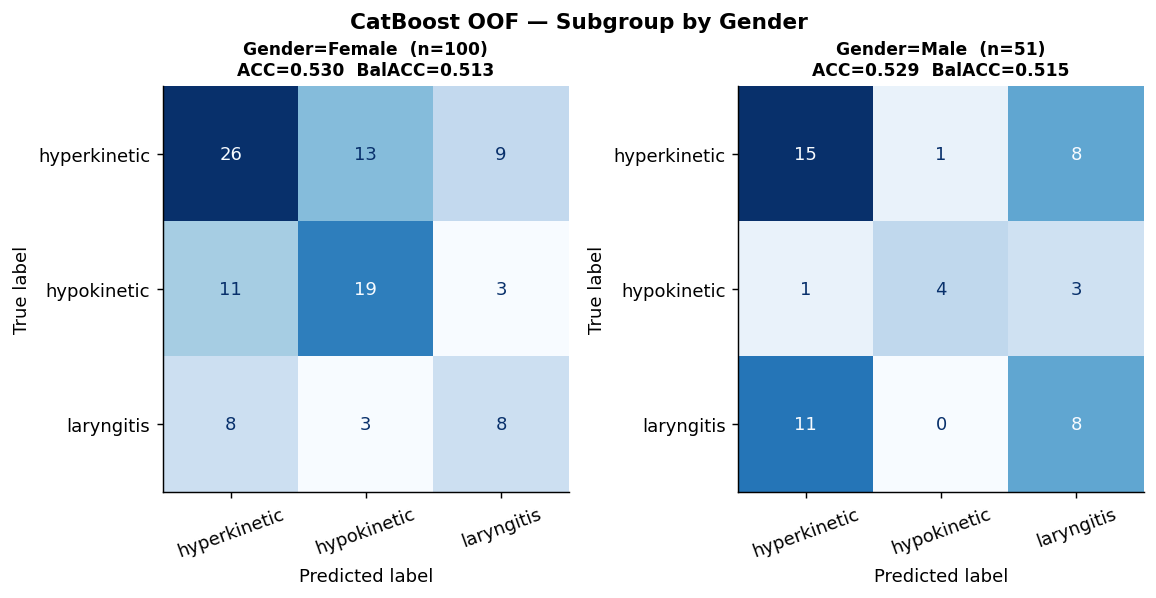

✅ saved: voiced_results/fig_subgroup_gender.png

  [Gender] BalACC by subgroup:
    Female: n=100  BalACC=0.513
    Male: n=51  BalACC=0.515

── Subgroup: Age ──


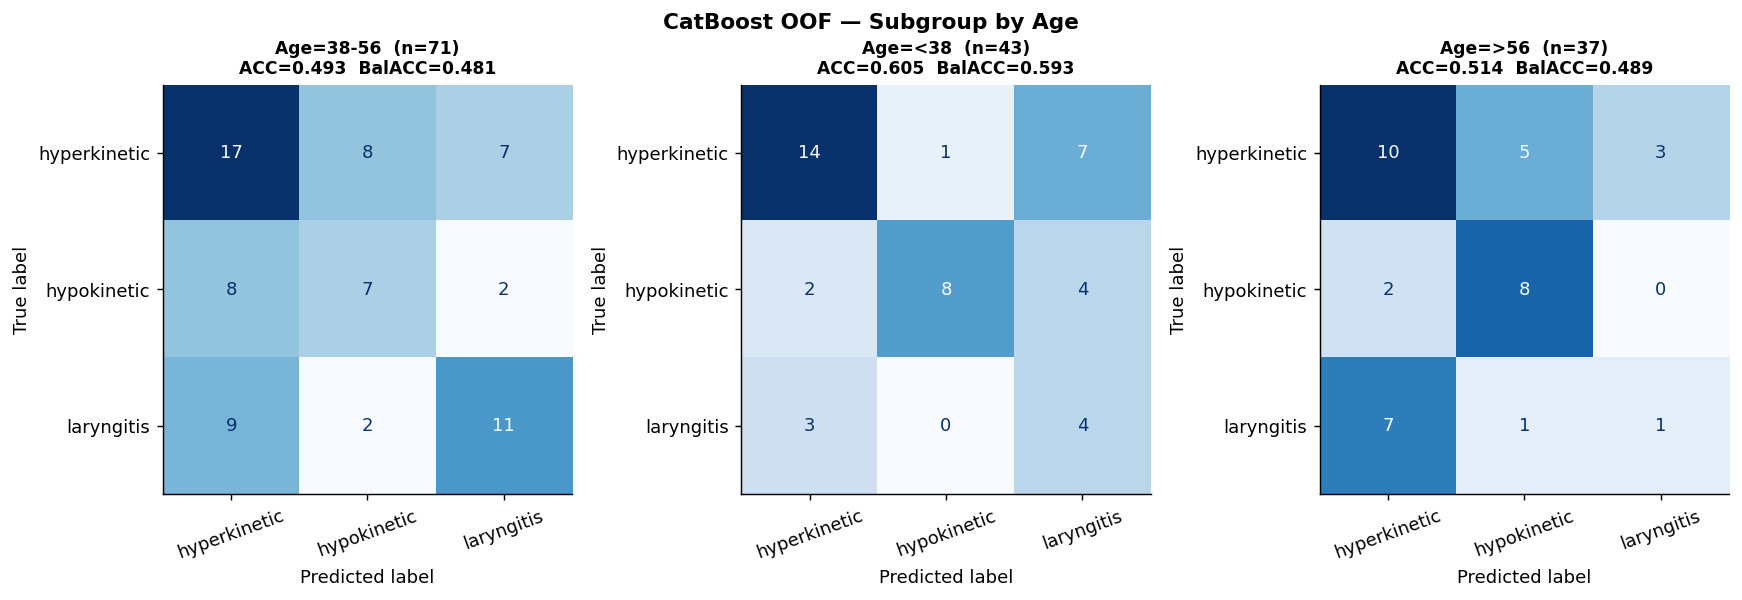

✅ saved: voiced_results/fig_subgroup_age.png

  [Age] BalACC by subgroup:
    38-56: n=71  BalACC=0.481
    <38: n=43  BalACC=0.593
    >56: n=37  BalACC=0.489

── Subgroup: VHI ──


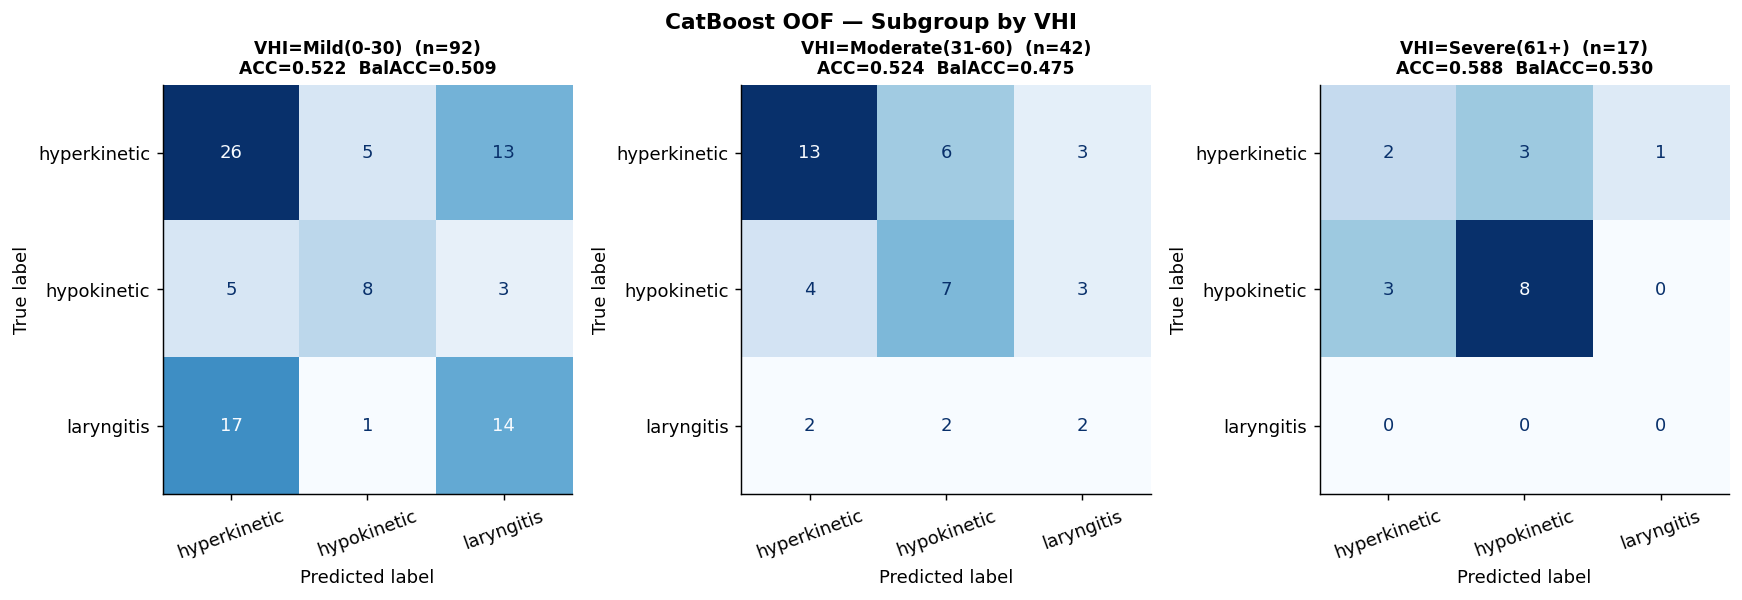

✅ saved: voiced_results/fig_subgroup_vhi.png

  [VHI] BalACC by subgroup:
    Mild(0-30): n=92  BalACC=0.509
    Moderate(31-60): n=42  BalACC=0.475
    Severe(61+): n=17  BalACC=0.530

── Subgroup: RSI ──


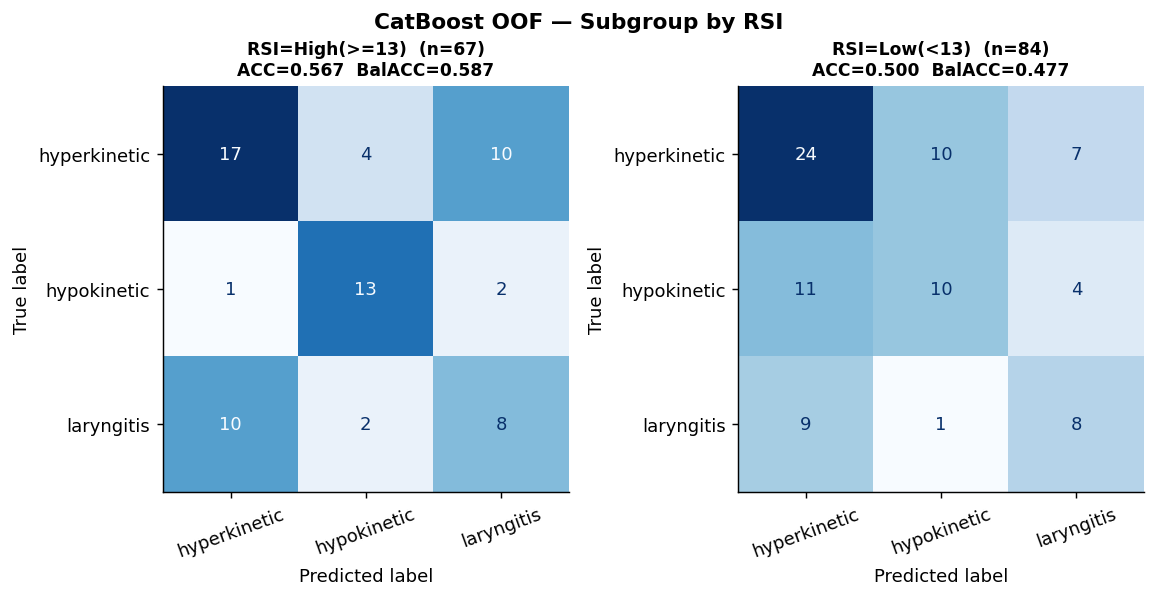

✅ saved: voiced_results/fig_subgroup_rsi.png

  [RSI] BalACC by subgroup:
    High(>=13): n=67  BalACC=0.587
    Low(<13): n=84  BalACC=0.477

subgroup analysis done


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# subgroup analysis
# 在 CatBoost 三分类结果上，按 age / gender / vhi / rsi 分组

import warnings
warnings.filterwarnings("ignore")

# 取 CatBoost 的 OOF 预测结果
y_oof_best = p1_results["CatBoost"]["y_oof"]

# 把预测结果拼回 dis_df
result_df = dis_df.copy()
result_df["y_pred"] = y_oof_best
result_df["correct"] = (result_df["y_pred"] == y_true_3).astype(int)
result_df["y_true"] = y_true_3

# 从 raw_upload 里把 metadata 拿过来
meta_cols = ["record_id", "age", "vhi", "rsi", "gender_male"]
available_meta = [c for c in meta_cols if c in raw_upload.columns]
meta_raw = (
    raw_upload[available_meta]
    .drop_duplicates(subset=["record_id"])
    .reset_index(drop=True)
)
result_df = result_df.merge(meta_raw, on="record_id", how="left")


# ── 分组函数 ────────────────────────────────────────────────────
def subgroup_confusion(df, group_col, group_label, bins=None, labels=None):

    if bins is not None:
        df = df.copy()
        df[group_col + "_group"] = pd.cut(df[group_col], bins=bins, labels=labels)
        group_col = group_col + "_group"

    groups = df[group_col].dropna().unique()
    groups = sorted([g for g in groups if str(g) != "nan"])
    n = len(groups)
    if n == 0:
        print(f"  no valid groups for {group_col}")
        return

    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
    if n == 1:
        axes = [axes]

    fig.suptitle(f"CatBoost OOF — Subgroup by {group_label}",
                 fontsize=12, fontweight="bold")

    for ax, grp in zip(axes, groups):
        sub = df[df[group_col] == grp]
        if len(sub) < 3:
            ax.set_title(f"{grp}\n(n too small)")
            continue
        cm = confusion_matrix(sub["y_true"], sub["y_pred"],
                              labels=[0, 1, 2])
        bal = balanced_accuracy_score(sub["y_true"], sub["y_pred"])
        acc = accuracy_score(sub["y_true"], sub["y_pred"])
        disp = ConfusionMatrixDisplay(cm, display_labels=DISEASE_ORDER)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{group_label}={grp}  (n={len(sub)})\n"
                     f"ACC={acc:.3f}  BalACC={bal:.3f}",
                     fontsize=9.5, fontweight="bold")
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/fig_subgroup_{group_label.lower().replace(' ','_')}.png"
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"✅ saved: {fname}")

    # print summary
    print(f"\n  [{group_label}] BalACC by subgroup:")
    for grp in groups:
        sub = df[df[group_col] == grp]
        if len(sub) < 3:
            continue
        bal = balanced_accuracy_score(sub["y_true"], sub["y_pred"])
        print(f"    {grp}: n={len(sub)}  BalACC={bal:.3f}")


# ── 1. Gender ───────────────────────────────────────────────────
if "gender_male" in result_df.columns:
    print("\n── Subgroup: Gender ──")
    result_df["gender"] = result_df["gender_male"].map({1.0: "Male", 0.0: "Female"})
    subgroup_confusion(result_df, "gender", "Gender")

# ── 2. Age group ────────────────────────────────────────────────
if "age" in result_df.columns:
    print("\n── Subgroup: Age ──")
    subgroup_confusion(
        result_df, "age", "Age",
        bins=[0, 38, 56, 80],
        labels=["<38", "38-56", ">56"]
    )

# ── 3. VHI group ────────────────────────────────────────────────
if "vhi" in result_df.columns:
    print("\n── Subgroup: VHI ──")
    # VHI 0-30 mild, 31-60 moderate, 61-120 severe
    subgroup_confusion(
        result_df, "vhi", "VHI",
        bins=[-1, 30, 60, 200],
        labels=["Mild(0-30)", "Moderate(31-60)", "Severe(61+)"]
    )

# ── 4. RSI group  ─────────────────────────────────────
if "rsi" in result_df.columns:
    print("\n── Subgroup: RSI ──")
    subgroup_confusion(
        result_df, "rsi", "RSI",
        bins=[-1, 13, 200],
        labels=["Low(<13)", "High(>=13)"]
    )

# 存存存 急急急
result_df.to_csv(f"{OUTPUT_DIR}/subgroup_predictions.csv", index=False)
print("\nsubgroup analysis done")

import shutil
shutil.make_archive("voiced_results", "zip", OUTPUT_DIR)
files.download("voiced_results.zip")